# 12. 예측 대상 바꾸기: 얼마나 → 어느 쪽으로

## Overview

11번에서 시금치 9월을 뜯어보다 알게 된 게 있습니다. **모델이 크게 번 건 정교하게
맞혀서가 아니었습니다.**

| 연도 | 실제 변화 | 모델 예측 | 방향 맞춘 비율 |
|---|---|---|---|
| 2023 | -43.9% | -25.1% | 89% |
| 2024 | -31.6% | -23.0% | 94% |

실제와 예측의 상관은 0.177 로 낮았습니다: 세부 등락은 전혀 못 맞힙니다. 그런데도
크게 번 이유는 **"내려간다"는 방향 하나를 맞혔기** 때문입니다.

그렇다면 처음부터 **방향만 묻는 문제**로 좁히면 어떨까요. 지금까지(02~11번)는 늘
"7거래일 뒤 몇 % 오를까"를 물었는데, 여기서는 **"오를까 내릴까"** 만 묻습니다.

## 무엇이 달라지나

| | 지금까지 (02~11번) | 이 문서 |
|---|---|---|
| 묻는 것 | 7거래일 뒤 몇 % 변할까 | 7거래일 뒤 오를까 내릴까 |
| 모델 종류 | 회귀 | 분류 |
| 성적 재는 법 | 평균 오차(MAPE) | **방향 적중률** |
| 기준선 | "그냥 두기"(안 변한다) | **50%** (동전 던지기) |

**적중률 50% 는 아무 정보 없이 찍어도 나오는 값입니다.** 그걸 넘는지, 넘는다면
어디서 넘는지가 이 문서의 질문입니다.

## 목차

1. 현황: 오르는 날과 내리는 날의 비율
2. 가설
3. 검증: 회귀 모델의 부호 vs 분류 모델
4. 어디서 잘 맞히는가
5. 결론

In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager
from sklearn.ensemble import (HistGradientBoostingClassifier,
                             HistGradientBoostingRegressor)

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
df = pd.read_parquet(ROOT / "notebooks" / ".cache" / "mart.parquet")
df["price_date"] = pd.to_datetime(df["price_date"])
df = df.sort_values(["item", "price_date"]).reset_index(drop=True)
items = sorted(df.item.unique())
print(f"{len(df):,}행 | 품목 {len(items)}개")

24,078행 | 품목 19개


## 1. 현황: 오르는 날과 내리는 날

먼저 확인할 게 있습니다. **오르는 날과 내리는 날이 반반이 아니면** 기준선이
50% 가 아닙니다.

예를 들어 오르는 날이 60% 라면, 아무 생각 없이 "항상 오른다"고 찍어도 60% 를
맞힙니다. 그러면 모델은 60% 를 넘어야 의미가 있습니다. 이걸 **찍기 기준선**
이라고 부르겠습니다.

In [2]:
H = 7
b = df.copy()
b["_logp"] = np.log(b.price_kg_avg)
b["y"] = b.groupby("item")._logp.shift(-H) - b._logp
b["오름"] = b.y > 0

bal = b.dropna(subset=["y"]).groupby("item").오름.agg(["mean", "size"])
bal.columns = ["오르는 날 비율", "일수"]
bal["오르는 날 비율"] = (bal["오르는 날 비율"] * 100).round(1)
bal["찍기 기준선"] = bal["오르는 날 비율"].apply(lambda p: round(max(p, 100 - p), 1))
display(bal.sort_values("찍기 기준선", ascending=False))

all_up = b.dropna(subset=["y"]).오름.mean() * 100
print(f"전체: 오르는 날 {all_up:.1f}%  ·  내리는 날 {100-all_up:.1f}%")
print(f"→ 전 품목 통틀어 찍기 기준선은 {max(all_up, 100-all_up):.1f}% 입니다.")

,오르는 날 비율,일수,찍기 기준선
item,,,
피마늘,26.4,641,73.6
깐마늘(국산),38.9,1366,61.1
브로콜리,56.4,706,56.4
감자,55.3,1364,55.3
시금치,53.4,1365,53.4
생강,46.7,1364,53.3
얼갈이배추,47.5,1365,52.5
깻잎,47.6,1365,52.4
파,47.6,1364,52.4


전체: 오르는 날 48.4%  ·  내리는 날 51.6%
→ 전 품목 통틀어 찍기 기준선은 51.6% 입니다.


## 2. 가설

| 가설 | 내용 | 맞다면 보여야 할 것 |
|---|---|---|
| **H1** | 방향만 묻는 문제로 바꾸면 방향을 더 잘 맞힌다 | 분류 모델 적중률 > 회귀 모델 부호 적중률 |
| **H2** | 적중률이 높은 곳은 11번에서 이득이 컸던 구간과 겹친다 | 품목·월별 적중률과 이득이 음의 상관 |

**H1 이 왜 말이 되나**: 회귀 모델은 "몇 %" 를 맞히려고 애쓰느라 손실의 상당 부분을
크기 맞추기에 씁니다. 방향만 물으면 그 노력이 전부 방향 판단에 갑니다.

**H1 이 틀릴 수도 있는 이유**: 방향과 크기가 한 몸일 수 있습니다. "크게 내려간다"는
신호가 곧 "내려간다"는 신호라면, 크기를 버려도 얻는 게 없습니다.

비교는 **똑같은 피처, 똑같은 폴드**로 합니다. 달라지는 건 예측 대상과 모델 종류뿐입니다.

In [3]:
EMBARGO = pd.Timedelta(days=int(H * 1.5))
FOLDS = [("2023-01-01", "2023-06-30"), ("2023-07-01", "2023-12-31"),
         ("2024-01-01", "2024-06-30"), ("2024-07-01", "2024-12-31"),
         ("2025-01-01", "2025-06-30"), ("2025-07-01", "2025-12-31"),
         ("2026-01-01", "2026-12-31")]
PARAMS = dict(learning_rate=0.014, max_iter=502, min_samples_leaf=21,
              max_leaf_nodes=15, l2_regularization=1.0)
CAL = ["month", "dayofweek", "days_to_major_holiday", "days_since_major_holiday",
       "days_since_solar_term"]


def g(c):
    return b.groupby("item")[c]


for lag in (1, 2, 3, 5, 10, 20):
    b[f"ret{lag}"] = b._logp - g("_logp").shift(lag)
for w in (5, 20, 60):
    mp = max(2, w // 3)
    b[f"dev{w}"] = b._logp - g("_logp").transform(
        lambda s: s.rolling(w, min_periods=mp).mean())
    b[f"vol{w}"] = g("_logp").transform(
        lambda s: s.diff().rolling(w, min_periods=mp).std())
doy = b.price_date.dt.dayofyear
b["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
b["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)
b["seas_dev"] = b._logp - (b.groupby(["item", "month"])["_logp"]
                           .transform(lambda s: s.shift(1).expanding(min_periods=20).mean()))
b["item_code"] = pd.Categorical(b.item, categories=items).codes
feat = b.dropna(subset=["y"]).reset_index(drop=True)

FEATS = ([f"ret{l}" for l in (1, 2, 3, 5, 10, 20)] + [f"dev{w}" for w in (5, 20, 60)]
         + [f"vol{w}" for w in (5, 20, 60)] + CAL
         + ["doy_sin", "doy_cos", "seas_dev", "item_code"])
CAT = [FEATS.index(c) for c in ("item_code", "month", "dayofweek")]

t0 = time.time()
out = []
for s, e in FOLDS:
    s, e = pd.Timestamp(s), pd.Timestamp(e)
    tr = feat[feat.price_date < s - EMBARGO]
    te = feat[(feat.price_date >= s) & (feat.price_date <= e)]

    reg = HistGradientBoostingRegressor(
        loss="absolute_error", categorical_features=CAT, early_stopping=False,
        random_state=42, **PARAMS).fit(tr[FEATS], tr.y)
    clf = HistGradientBoostingClassifier(
        categorical_features=CAT, early_stopping=False,
        random_state=42, **PARAMS).fit(tr[FEATS], tr.오름)

    t = te[["item", "price_date", "month", "y", "오름"]].copy()
    t["회귀예측"] = reg.predict(te[FEATS])
    t["분류확률"] = clf.predict_proba(te[FEATS])[:, 1]
    out.append(t)
r = pd.concat(out).reset_index(drop=True)

r["회귀_방향맞음"] = (r.회귀예측 > 0) == r.오름
r["분류_방향맞음"] = (r.분류확률 > 0.5) == r.오름
print(f"완료 ({time.time()-t0:.0f}초, {len(r):,}일)")

완료 (26초, 15,762일)


## 3. 검증: 회귀의 부호 vs 분류

같은 피처·같은 폴드에서 두 모델을 나란히 놓습니다.

- **회귀 모델의 부호**: "몇 % 오를까"를 예측한 뒤 그 값이 양수면 상승으로 봅니다
- **분류 모델**: 처음부터 "오를 확률"을 직접 예측합니다

In [4]:
def 적중(s):
    up = s.오름.mean()
    return pd.Series({
        "일수": len(s),
        "찍기 기준선": max(up, 1 - up) * 100,
        "회귀 부호": s.회귀_방향맞음.mean() * 100,
        "분류": s.분류_방향맞음.mean() * 100,
    })


per = r.groupby("item").apply(적중, include_groups=False)
per["분류-회귀"] = (per["분류"] - per["회귀 부호"]).round(1)
per["분류-기준선"] = (per["분류"] - per["찍기 기준선"]).round(1)
display(per.round(1).sort_values("분류-기준선", ascending=False))

all_ = 적중(r)
print(f"전체 {len(r):,}일")
print(f"  찍기 기준선 {all_['찍기 기준선']:.1f}%")
print(f"  회귀 부호   {all_['회귀 부호']:.1f}%")
print(f"  분류        {all_['분류']:.1f}%")

,일수,찍기 기준선,회귀 부호,분류,분류-회귀,분류-기준선
item,,,,,,
풋고추,871.0,52.1,65.4,68.1,2.6,16.0
미나리,870.0,53.3,68.3,69.0,0.7,15.6
상추,871.0,52.7,66.5,67.0,0.6,14.4
얼갈이배추,871.0,53.8,67.2,67.7,0.6,13.9
양배추,871.0,51.3,62.1,64.6,2.5,13.3
열무,871.0,50.3,61.4,63.1,1.7,12.9
시금치,871.0,53.6,67.2,65.7,-1.5,12.1
알배기배추,769.0,51.6,64.9,63.5,-1.4,11.8
배추,870.0,52.0,61.0,63.4,2.4,11.5


전체 15,762일
  찍기 기준선 51.1%
  회귀 부호   61.2%
  분류        62.8%


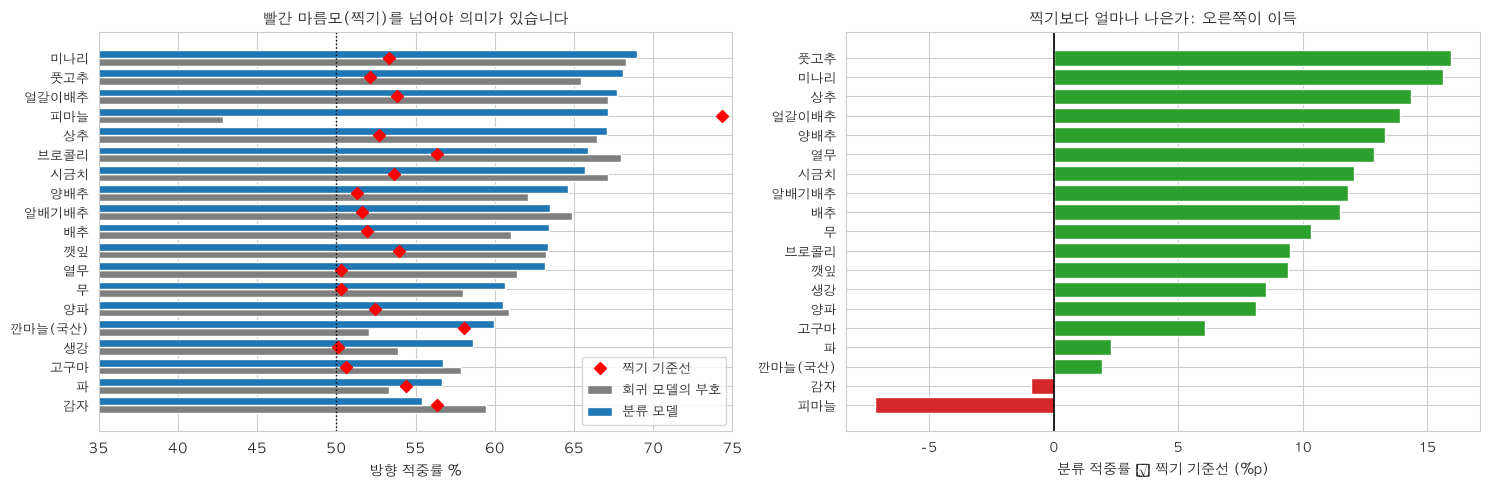

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
p = per.sort_values("분류")
yy = np.arange(len(p))
ax.barh(yy - 0.2, p["회귀 부호"], height=0.4, color="tab:gray", label="회귀 모델의 부호")
ax.barh(yy + 0.2, p["분류"], height=0.4, color="tab:blue", label="분류 모델")
ax.plot(p["찍기 기준선"], yy, "rD", ms=6, label="찍기 기준선")
ax.axvline(50, color="black", ls=":", lw=1)
ax.set_yticks(yy)
ax.set_yticklabels(p.index, fontsize=9)
ax.set_xlim(35, 75)
ax.set_xlabel("방향 적중률 %")
ax.set_title("빨간 마름모(찍기)를 넘어야 의미가 있습니다", fontsize=11)
ax.legend(fontsize=9, loc="lower right")

ax = axes[1]
gain = (per["분류"] - per["찍기 기준선"]).sort_values()
cols = ["tab:green" if v > 0 else "tab:red" for v in gain]
ax.barh(gain.index, gain.values, color=cols)
ax.axvline(0, color="black", lw=1.2)
ax.set_xlabel("분류 적중률 − 찍기 기준선 (%p)")
ax.set_title("찍기보다 얼마나 나은가: 오른쪽이 이득", fontsize=11)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.show()

## 4. 어디서 잘 맞히는가

H2 확인입니다. 11번에서 모델이 크게 벌었던 구간(시금치 9월 같은)에서 방향
적중률도 높은지 봅니다. 겹친다면 **"방향을 맞히는 것이 이득의 정체"** 라는
설명이 힘을 얻습니다.

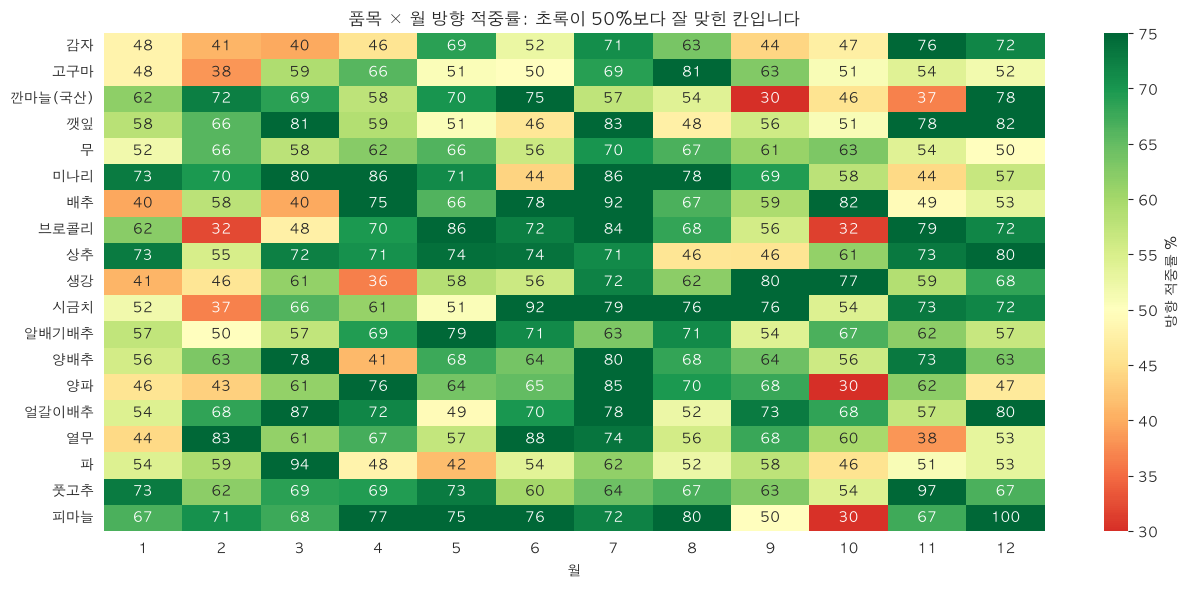

가장 잘 맞히는 칸 10개
 item  month   적중률   일수
  피마늘     12 100.0 16.0
  풋고추     11  96.8 63.0
    파      3  94.0 83.0
  시금치      6  92.5 80.0
   배추      7  91.9 86.0
   열무      6  87.5 80.0
얼갈이배추      3  86.7 83.0
  미나리      7  86.0 86.0
 브로콜리      5  86.0 57.0
  미나리      4  85.9 85.0

가장 못 맞히는 칸 10개
   item  month  적중률   일수
     양파     10 29.8 57.0
깐마늘(국산)      9 30.0 60.0
    피마늘     10 30.2 43.0
   브로콜리     10 31.6 38.0
   브로콜리      2 32.1 56.0
     생강      4 36.5 85.0
깐마늘(국산)     11 36.5 63.0
    시금치      2 36.8 76.0
     열무     11 38.1 63.0
    고구마      2 38.2 76.0


In [6]:
cell = (r.groupby(["item", "month"])
         .apply(lambda s: pd.Series({"적중률": s.분류_방향맞음.mean() * 100,
                                     "일수": len(s)}), include_groups=False)
         .reset_index())
cell = cell[cell.일수 >= 15]
piv = cell.pivot(index="item", columns="month", values="적중률")

fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(piv, annot=True, fmt=".0f", cmap="RdYlGn", center=50,
            vmin=30, vmax=75, ax=ax, cbar_kws={"label": "방향 적중률 %"})
ax.set_title("품목 × 월 방향 적중률: 초록이 50%보다 잘 맞힌 칸입니다", fontsize=12)
ax.set_xlabel("월")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

print("가장 잘 맞히는 칸 10개")
print(cell.nlargest(10, "적중률").round(1).to_string(index=False))
print("\n가장 못 맞히는 칸 10개")
print(cell.nsmallest(10, "적중률").round(1).to_string(index=False))

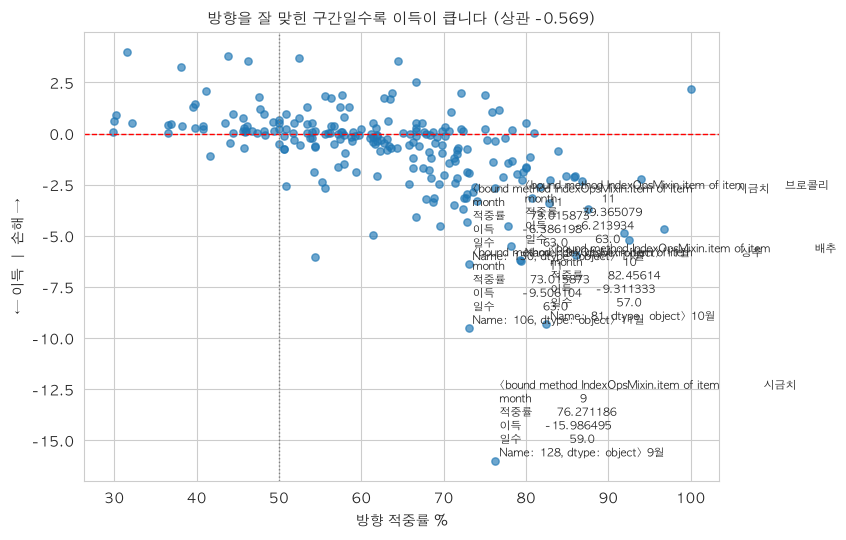

적중률과 이득의 Spearman 상관: -0.569
(이득은 음수가 좋으므로 음의 상관이 나와야 '적중률이 높으면 이득'입니다)


In [7]:
# 11번의 '이득' 과 방향 적중률이 겹치는가
r["모델오차"] = np.abs(np.exp(r.회귀예측) - np.exp(r.y)) / np.exp(r.y) * 100
r["그냥둘때오차"] = np.abs(1 - np.exp(r.y)) / np.exp(r.y) * 100
r["이득"] = r.모델오차 - r.그냥둘때오차

cmp = (r.groupby(["item", "month"])
        .apply(lambda s: pd.Series({"적중률": s.분류_방향맞음.mean() * 100,
                                    "이득": s.이득.mean(),
                                    "일수": len(s)}), include_groups=False)
        .reset_index())
cmp = cmp[cmp.일수 >= 15]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.scatter(cmp.적중률, cmp.이득, s=28, alpha=0.65)
ax.axhline(0, color="red", ls="--", lw=1)
ax.axvline(50, color="gray", ls=":", lw=1)
for _, row in cmp.nsmallest(5, "이득").iterrows():
    ax.annotate(f"{row.item} {int(row.month)}월", (row.적중률, row.이득),
                fontsize=8, xytext=(3, 3), textcoords="offset points")
sp = cmp.적중률.corr(cmp.이득, method="spearman")
ax.set_xlabel("방향 적중률 %")
ax.set_ylabel("← 이득  |  손해 →")
ax.set_title(f"방향을 잘 맞힌 구간일수록 이득이 큽니다 (상관 {sp:.3f})", fontsize=11)
plt.tight_layout()
plt.show()
print(f"적중률과 이득의 Spearman 상관: {sp:.3f}")
print("(이득은 음수가 좋으므로 음의 상관이 나와야 '적중률이 높으면 이득'입니다)")

## 5. 결론

### 한 줄 요약

**방향은 진작부터 맞히고 있었습니다.** 그동안 "예측이 안 된다"고 본 것은
크기를 못 맞힌 것이었습니다.

### 가설 판정

| 가설 | 내용 | 결과 | 판정 |
|---|---|---|---|
| **H1** | 방향만 물으면 더 잘 맞힌다 | 분류 62.8% > 회귀 부호 61.2% | **확인됨** (다만 차이는 1.6%p) |
| **H2** | 잘 맞히는 곳이 이득 구간과 겹친다 | 적중률·이득 상관 **-0.569** | **확인됨** |

전체 성적입니다. 찍기 기준선은 51.1% 입니다: 오르는 날 48.4% · 내리는 날 51.6% 라
"항상 내린다"고 찍으면 51.6% 를 맞힙니다.

| 방법 | 적중률 | 찍기 대비 |
|---|---|---|
| 찍기 기준선 | 51.1% | — |
| 회귀 모델의 부호 | 61.2% | +10.1%p |
| **분류 모델** | **62.8%** | **+11.7%p** |

### 품목 판정이 뒤집힙니다

11번까지는 변화율(몇 % 오를까)로만 재서 파·무·양배추를 "안 되는 품목"으로
분류했습니다. **방향으로 재면 다르게 보입니다.**

| 품목 | 방향 적중 (찍기 대비) | 변화율 이득 | 읽는 법 |
|---|---|---|---|
| 풋고추 | **+16.0%p** | -1.41 | 둘 다 잘 됨 |
| 미나리 | **+15.6%p** | -1.55 | 둘 다 잘 됨 |
| **양배추** | **+13.3%p** | -0.15 | **방향만 잘 됨** |
| **무** | **+10.3%p** | +0.08 | **방향만 잘 됨** |
| 파 | +2.3%p | +0.22 | 둘 다 안 됨 |
| 감자 | -0.9%p | -0.07 | 둘 다 안 됨 |
| 피마늘 | -7.2%p | +0.96 | 방향 자체가 무의미 |

**양배추와 무가 재평가됩니다.** 변화율로는 실패였는데 방향으로는 10%p 넘게
찍기를 이깁니다. "오를지 내릴지는 아는데 얼마나일지를 모르는" 품목입니다.

### 피마늘은 예외로 다뤄야 합니다

찍기 기준선이 **74.3%** 입니다: 오르는 날이 26.4% 뿐이라 "항상 내린다"고 찍으면
74% 를 맞힙니다. 분류 모델은 67.1% 로 그보다 못합니다. 10번에서 본 대로 가격이
89.8% 의 날에 멈춰 있어, 방향이라는 개념 자체가 흐릿한 품목입니다.

### 한계

- **분류가 회귀 부호보다 1.6%p 나은 데 그칩니다.** 예측 대상을 바꿔 얻은 것보다,
  "방향이라는 척도로 재니 그동안 성과가 보인다"는 쪽이 더 큰 발견입니다.
- 적중률 62.8% 가 실무에서 쓸 만한 수준인지는 **용도에 달렸습니다.** 이 문서는
  그 판단을 하지 않습니다.
- 정체 품목(피마늘·깐마늘·생강)은 찍기 기준선 자체가 높아 비교가 왜곡됩니다.

### 다음에 해볼 만한 것

1. **확신도를 쓴다**: 분류 모델은 확률을 냅니다. 0.5 근처(애매한 날)를 빼고
   확신하는 날만 골랐을 때 적중률이 오르는지 봅니다. 11번에서 회귀 예측 크기로
   가르려다 실패했는데, 확률로는 다를 수 있습니다.
2. **방향과 크기를 나눠 쓴다**: 방향은 분류로, 크기는 별도로 다루는 2단 구조.
3. **용도를 정한다**: 방향 예측이 무엇에 쓰일지 정해야 62.8% 가 충분한지 판단할
   수 있습니다.

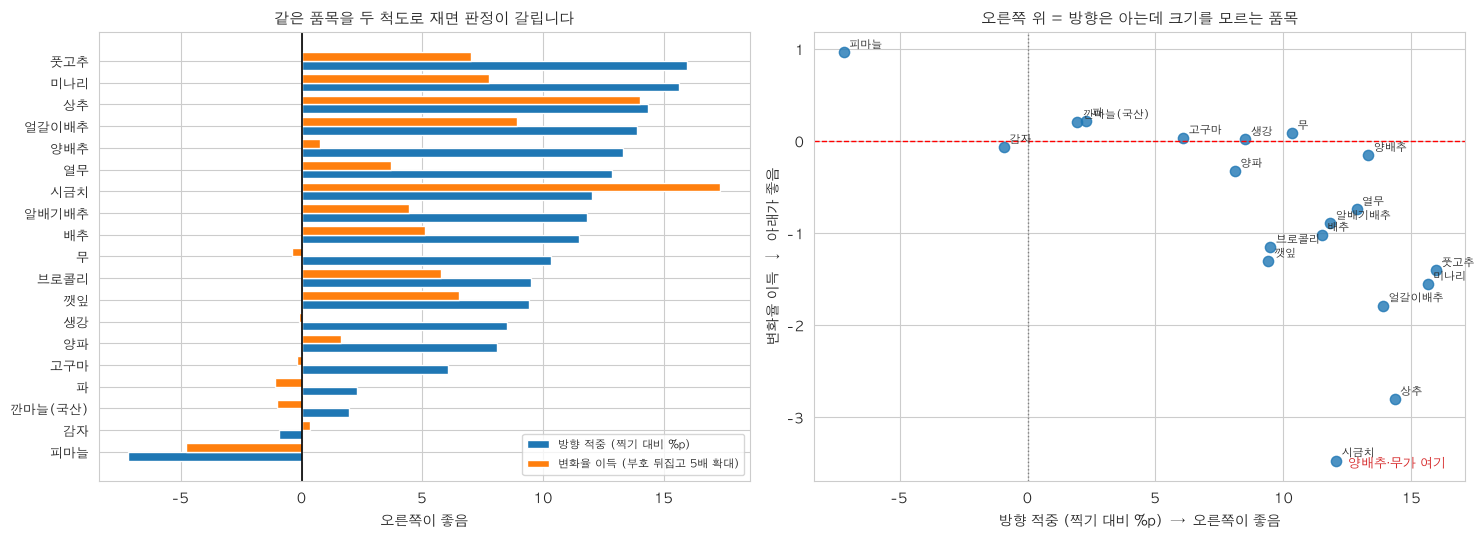

결론 요약 테이블


,찍기 기준선,분류,방향이득,변화율이득
item,,,,
풋고추,52.12,68.08,15.96,-1.41
미나리,53.33,68.97,15.63,-1.55
상추,52.70,67.05,14.35,-2.80
얼갈이배추,53.85,67.74,13.89,-1.79
양배추,51.32,64.64,13.32,-0.15
열무,50.29,63.15,12.86,-0.74
시금치,53.62,65.67,12.06,-3.47
알배기배추,51.63,63.46,11.83,-0.89
배추,51.95,63.45,11.49,-1.02


In [8]:
# 결론 요약 그래프: 방향은 맞히는데 크기는 못 맞힙니다
summary = per[["찍기 기준선", "분류"]].copy()
summary["방향이득"] = summary["분류"] - summary["찍기 기준선"]
summary["변화율이득"] = r.groupby("item").이득.mean()
summary = summary.sort_values("방향이득")

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (1) 두 척도를 나란히
ax = axes[0]
yy = np.arange(len(summary))
ax.barh(yy - 0.2, summary.방향이득, height=0.4, color="tab:blue",
        label="방향 적중 (찍기 대비 %p)")
ax.barh(yy + 0.2, -summary.변화율이득 * 5, height=0.4, color="tab:orange",
        label="변화율 이득 (부호 뒤집고 5배 확대)")
ax.axvline(0, color="black", lw=1.2)
ax.set_yticks(yy)
ax.set_yticklabels(summary.index, fontsize=9)
ax.set_xlabel("오른쪽이 좋음")
ax.set_title("같은 품목을 두 척도로 재면 판정이 갈립니다", fontsize=11)
ax.legend(fontsize=8, loc="lower right")

# (2) 산점도: 오른쪽 아래로 갈수록 '방향만 되는' 품목
ax = axes[1]
ax.scatter(summary.방향이득, summary.변화율이득, s=55, alpha=0.8)
for it, row in summary.iterrows():
    ax.annotate(it, (row.방향이득, row.변화율이득), fontsize=8,
                xytext=(4, 3), textcoords="offset points")
ax.axhline(0, color="red", ls="--", lw=1)
ax.axvline(0, color="gray", ls=":", lw=1)
ax.set_xlabel("방향 적중 (찍기 대비 %p)  →  오른쪽이 좋음")
ax.set_ylabel("변화율 이득  ↓  아래가 좋음")
ax.set_title("오른쪽 위 = 방향은 아는데 크기를 모르는 품목", fontsize=11)
ax.text(0.97, 0.03, "양배추·무가 여기", transform=ax.transAxes,
        ha="right", fontsize=9, color="tab:red")

plt.tight_layout()
plt.show()

print("결론 요약 테이블")
display(summary.round(2).sort_values("방향이득", ascending=False))